# Symplectization

## Particle under the influence of an electric field

The system to work with (explained in detail in the [main document](https://www.overleaf.com/8939674148ymdnppkcnxpr#3514af)) has the following Hamiltonian:
$$
H(q,p,t) = \frac{ \|p\|^2 }{2m} - e\, q \cdot E(t).
$$
from which the Hamiltonian equations can be derived:
$$
\begin{array}{c}
\dot q := \frac{\partial H}{\partial p} = \frac{p}{m}, &
\dot p := -\frac{\partial H}{\partial q} = e \cdot E(t), &
\dot t := \frac{\partial t}{\partial t} = 1
\end{array}
$$

## The proposed modification

The Hamiltonian equations can be preserved even if the Hamiltonian is multiplied by a real-valued function of another variable (i.e., different from $p, q$ and $t$). This yields, inevitably (unless the function is $f(x) = 1 \,\, \forall x$), another Hamiltonian function which must (?) be equal to the original Hamiltonian function for some value of $f$. To put it briefly, if $f: U \overset{ab}{\subseteq} \mathbb{R} \to \mathbb{R}$ then
$$
\tilde{H} := H(q, p, t, r) = f(r)H(p, q, s)
$$
this Hamiltonian's equations are the following:
$$
\begin{array}{c}
\dot q := \frac{\partial \tilde{H}}{\partial p} = \frac{p}{m}, &
\dot p := - \frac{\partial \tilde{H}}{\partial q} = e \cdot E(t), &
\dot t := \frac{\partial t}{\partial t} = 1, &
\dot r := - \frac{\partial \tilde{H}}{\partial t}
\end{array}
$$
as you can see, they are pretty much the same as the original ones except the Hamiltonian has changed and now there are four different equations and the configuration space, in turn, is now an open subset of $\mathbb{R}^4$.

In consequence, we are now working in an even-dimensional space whose 2-form is the sum of two 2-forms: one relating to $p$ and $q$, and another one relating $r$ and $t$. As such, we could, in theory, apply symplectic integrators to the two pair of variables separately and it should not affect the overall result


## Implementation

In [4]:
import math
from typing import Tuple

import pandas as pd
import numpy as np

def f(r: np.ndarray) -> float:
    return r[0]

def df_dr(r: np.ndarray) -> float:
    return 1

def E(s: np.ndarray) -> np.ndarray:
    # return np.array([np.sin(s/2), np.cos(s/2)])
    return np.array(np.sin(s/2))

def dE_ds(s: np.ndarray) -> np.ndarray:
    # return (1/2) * np.array([np.cos(s/2), - np.sin(s/2)])
    return (1/2) * np.array(np.cos(s/2))

def symplectic_step(p_n: np.ndarray, r_n: np.ndarray, q_n: np.ndarray, t_n: np.ndarray, E: callable, dE_ds: callable, f: callable, df_dr: callable, h: np.ndarray = 0.1, charge: float = 1, m: float = 1, C: float = 0) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
    p_np1: np.ndarray = p_n + h * charge * E(t_n + C)
    r_np1: np.ndarray = r_n + h * charge * q_n * dE_ds(t_n + C)
    q_np1: np.ndarray = q_n + h * f(r_np1) * p_np1
    t_np1: float = t_n + (h/m) * df_dr(r_np1) * (np.linalg.norm(p_np1)**2) #*standard 2-euclidean norm
    # print(h * charge * q_n * dE_ds(t_n + C))

    return p_np1, r_np1, q_np1, t_np1

def SI_simplectization(p0: np.ndarray, r0: np.ndarray, q0: np.ndarray, t0: float, t_target: float, E: callable, dE_ds: callable, f: callable, df_dr: callable, charge: float = 1, m: float = 1, C: float = 0, n_steps: int = 10) -> pd.DataFrame:   
    if t_target < t0:
        raise ValueError(f"Target time {t_target} must be greater or equal than the initial time {t0}")
    if t_target == t0:
        print(f"Warning, initial time is the same as target time ({t_target}), so the output will be the initial values")
        return p0, r0, q0, t0
    
    h: float = (t_target - t0)/n_steps
    results: pd.DataFrame = pd.DataFrame({'p': [p0], 'r': [r0], 'q': [q0], 't': [t0]}, dtype=object)
    p_n: np.ndarray = p0
    r_n: np.ndarray = r0
    q_n: np.ndarray = q0
    t_n: np.ndarray = t0
    for i in range(n_steps):
        if i > 0:
            p_n, r_n, q_n, t_n = symplectic_step(p_n, r_n, q_n, t_n, E, dE_ds, f, df_dr, h, charge, m, C)
        else:
            p_n, r_n, q_n, t_n = symplectic_step(p_n, r_n, q_n, t_n, E, dE_ds, f, df_dr, h, charge, m, C)

        #*Add nth step to results
        nth_step_results: pd.DataFrame = pd.DataFrame({'p': [p_n], 'r': [r_n], 'q': [q_n], 't': [t_n]}, dtype=object)
        results = pd.concat([results, nth_step_results], ignore_index=True)

    return results

In [14]:
p0: np.ndarray = np.array([0])
q0: np.ndarray = np.array([1])
r0: np.ndarray = np.array([0])
t0: np.ndarray = np.array([0])
result: pd.DataFrame = SI_simplectization(p0=p0, r0=r0, q0=q0, t0=t0, t_target=np.array([40]), E=E, dE_ds=dE_ds, f=f, df_dr=df_dr, charge=1, m=1, C=-1, n_steps=10000)
result

,p,r,q,t
0,[0],[0],[1],[0]
1,[-0.001917702154416812],[0.0017551651237807456],[0.9999999865364643],[1.4710326212219531e-08]
2,[-0.0038354042830145724],[0.003510330230983269],[0.9999999326823219],[7.355163026888564e-08]
3,[-0.005753106308336127],[0.0052654952718728994],[0.9999998115105057],[2.059445590489534e-07]
4,[-0.007670808101286221],[0.007020660163558511],[0.9999995960939582],[4.4130974675598665e-07]
...,...,...,...,...
9996,[-0.7200252017098056],[-269.78325386703864],[697.4859342547468],[39.397668829273464]
9997,[-0.7186563218923382],[-268.4725105792664],[698.2576921226752],[39.39973469690945]
9998,[-0.7172835605452608],[-267.16081132838383],[699.0242123546263],[39.40179267973436]
9999,[-0.7159069339395245],[-265.84816654669936],[699.7855025378499],[39.403842770686616]


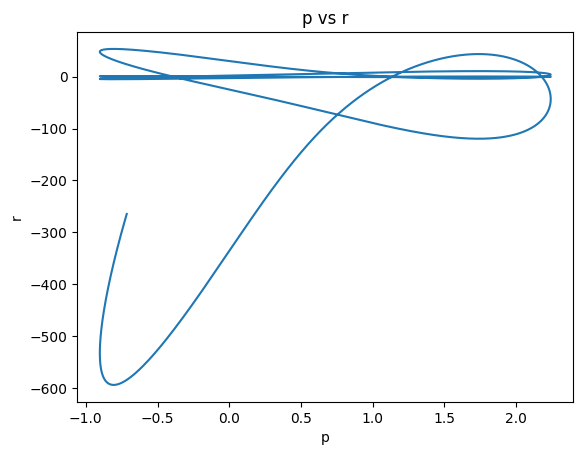

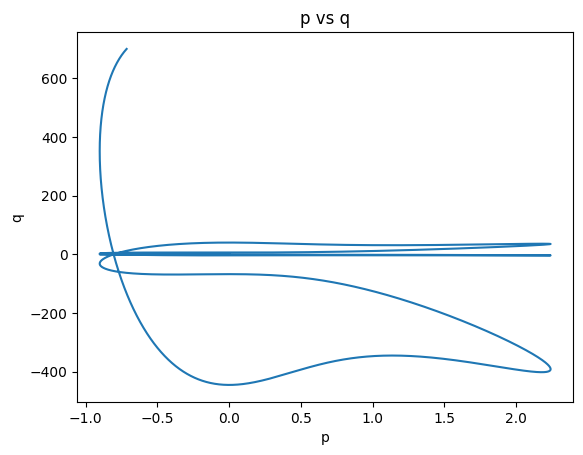

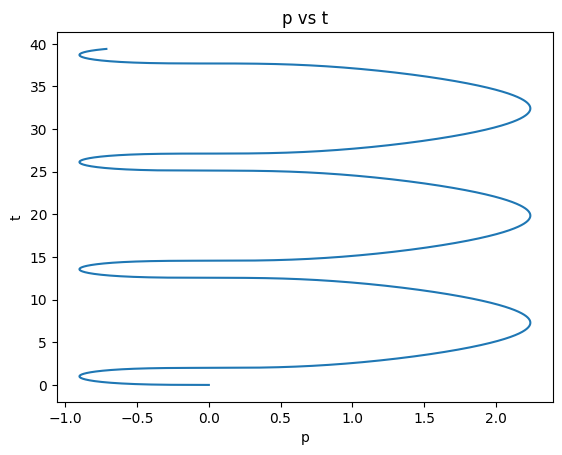

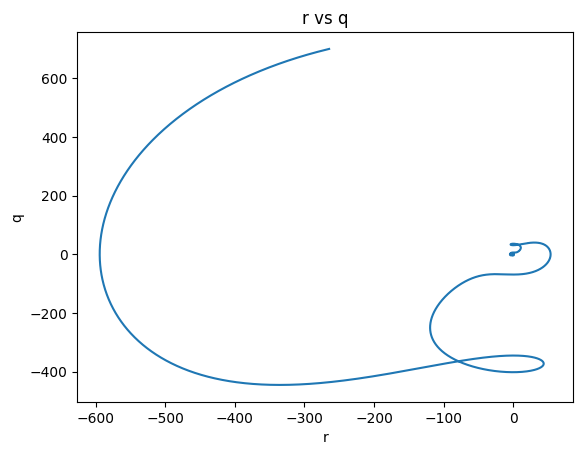

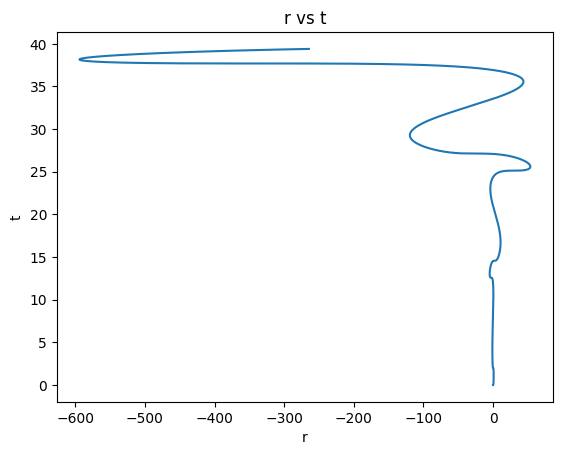

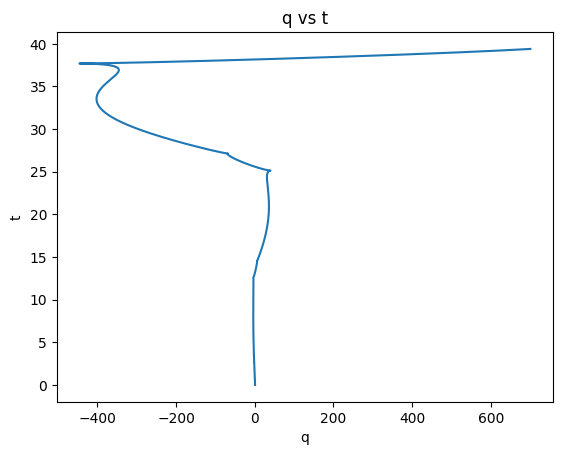

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def flatten_column(col):
    pieces = []
    for cell in col:
        arr = np.asarray(cell)
        pieces.append(arr.ravel())
    return np.concatenate(pieces)

def plot_column_pairs(df, cols=None):
    cols = df.columns if cols is None else cols
    for x_name, y_name in combinations(cols, 2):
        x = flatten_column(df[x_name])
        y = flatten_column(df[y_name])
        n = min(len(x), len(y))
        x, y = x[:n], y[:n]

        plt.figure()
        plt.plot(x, y, color='C0')  # base line
        # arrows between successive points
        plt.quiver(
            x[:-1], y[:-1],              # starting points
            np.diff(x), np.diff(y),      # delta to next point
            angles='xy', scale_units='xy', scale=1,
            width=0.001, color=(0.1, 0.4, 0.8, 0.5),
            headwidth=25, headlength=30, headaxislength=30
        )
        plt.title(f"{x_name} vs {y_name}")
        plt.xlabel(x_name)
        plt.ylabel(y_name)
    plt.show()

plot_column_pairs(result, None)
